Column Names: Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='str')
------------------------------
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scor

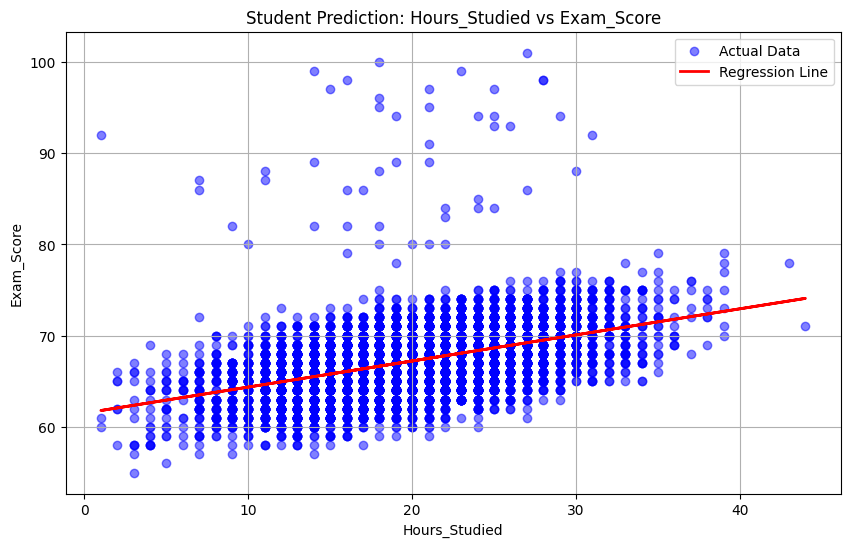

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


df = pd.read_csv('spf.csv')


print("Column Names:", df.columns)
print("-" * 30)
print(df.head())


feature_col = 'Hours_Studied'  
target_col = 'Exam_Score'      


if feature_col not in df.columns or target_col not in df.columns:
    print(f"\n⚠️ ERROR: Could not find '{feature_col}' or '{target_col}'.")
    print("Please update the 'feature_col' and 'target_col' variables above to match your CSV.")
else:
  
    X = df[[feature_col]]
    y = df[target_col]

    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  
    model = LinearRegression()
    model.fit(X_train, y_train) 

    print(f"\nModel Intercept: {model.intercept_:.2f}")
    print(f"Model Slope: {model.coef_[0]:.2f}")

  
    y_pred = model.predict(X_test)
    
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"R2 Score: {r2:.2f}") 

    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, color='blue', alpha=0.5, label='Actual Data')
    plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')
    plt.title(f'Student Prediction: {feature_col} vs {target_col}')
    plt.xlabel(feature_col)
    plt.ylabel(target_col)
    plt.legend()
    plt.grid(True)
    plt.show()

Linear Regression R2 Score:     0.1984
Polynomial Regression R2 Score: 0.1988
>> Conclusion: The Polynomial (Curved) model fits the data BETTER.


/home/muqeet/myenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


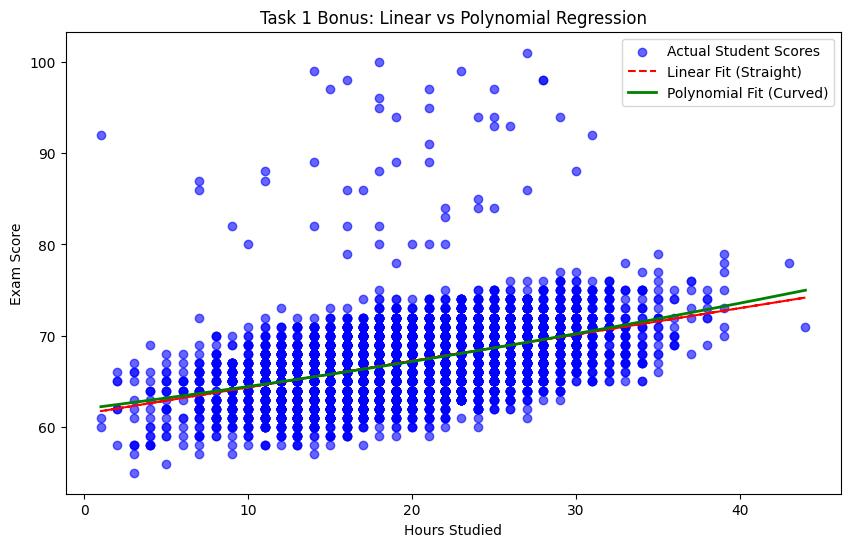

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

df = pd.read_csv('spf.csv')

X = df[['Hours_Studied']]
y = df['Exam_Score']

lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_linear = lin_reg.predict(X)
r2_linear = r2_score(y, y_pred_linear)

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
y_pred_poly = poly_reg.predict(X_poly)
r2_poly = r2_score(y, y_pred_poly)

print(f"Linear Regression R2 Score:     {r2_linear:.4f}")
print(f"Polynomial Regression R2 Score: {r2_poly:.4f}")

if r2_poly > r2_linear:
    print(">> Conclusion: The Polynomial (Curved) model fits the data BETTER.")
else:
    print(">> Conclusion: The Linear model is sufficient; the curve didn't help much.")

plt.figure(figsize=(10, 6))

plt.scatter(X, y, color='blue', alpha=0.6, label='Actual Student Scores')

plt.plot(X, y_pred_linear, color='red', linestyle='--', label='Linear Fit (Straight)')

X_seq = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
X_seq_poly = poly.transform(X_seq)
plt.plot(X_seq, poly_reg.predict(X_seq_poly), color='green', linewidth=2, label='Polynomial Fit (Curved)')

plt.title('Task 1 Bonus: Linear vs Polynomial Regression')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend()
plt.show()